# Lissajous Figures Trainer

This notebook explores **Lissajous figures** — beautiful curves formed by the composition of two (or three) periodic motions at different frequencies.

## Learning Objectives
- Understand parametric equations and how frequencies create patterns
- Explore the relationship between frequency ratios and closed curves
- Extend Lissajous figures to 3D
- Predict which parameter combinations give closed curves

## 1. Parametric Equations

A **2D Lissajous figure** is defined by:

$$x(t) = A \cos(a t + \delta)$$
$$y(t) = B \sin(b t)$$

where:
- $A$, $B$ are amplitudes
- $a$, $b$ are frequency parameters
- $\delta$ is a phase offset

The shape depends on:
- The **frequency ratio** $a:b$ — determines the pattern
- The **phase** $\delta$ — rotates/distorts the pattern

Special cases:
- $a = b$, $\delta = 0$: diagonal line
- $a = b$, $\delta = \pi/2$: circle (if $A = B$) or ellipse
- $a = 2b$, $\delta = 0$: figure-8 (parabola)

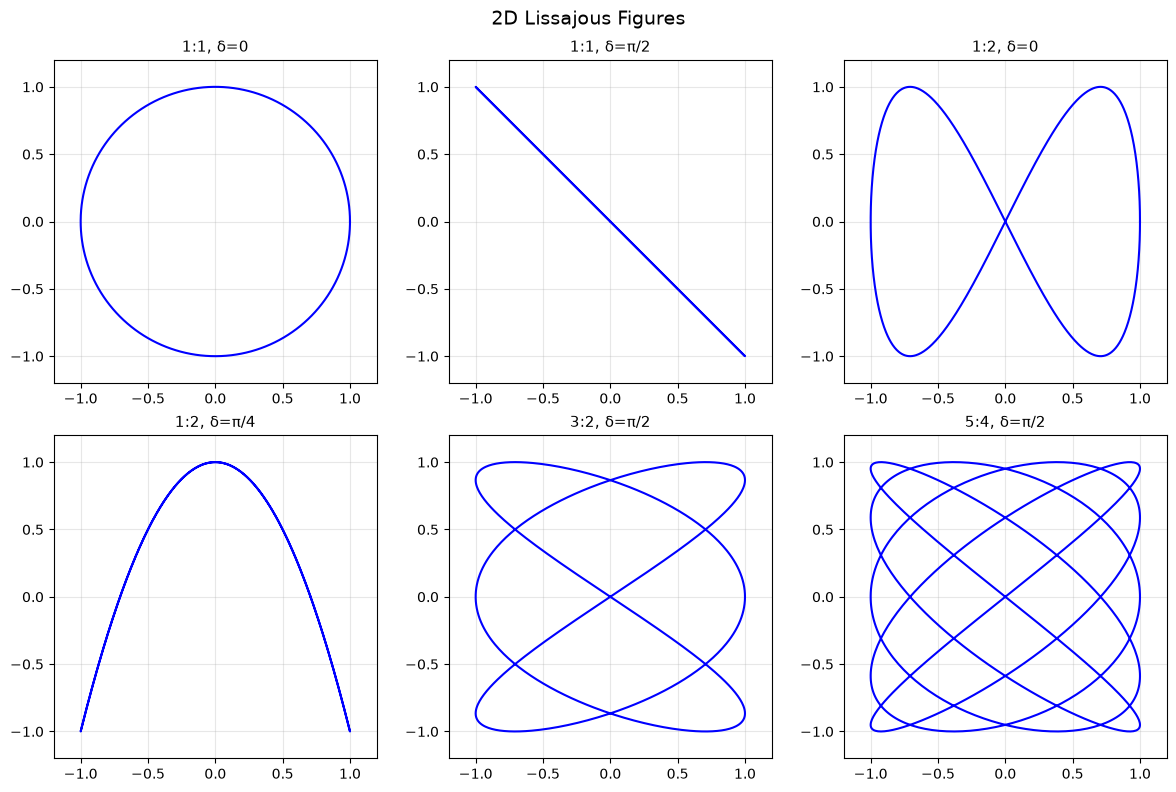

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def lissajous_2d(a, b, delta=0.0, A=1.0, B=1.0, n_points=1000):
    """Generate a 2D Lissajous curve."""
    t = np.linspace(0, 2 * np.pi, n_points)
    x = A * np.cos(a * t + delta)
    y = B * np.sin(b * t)
    return x, y

# Basic examples
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

params = [
    (1, 1, 0, '1:1, δ=0'),
    (1, 1, np.pi/2, '1:1, δ=π/2'),
    (1, 2, 0, '1:2, δ=0'),
    (1, 2, np.pi/4, '1:2, δ=π/4'),
    (3, 2, np.pi/2, '3:2, δ=π/2'),
    (5, 4, np.pi/2, '5:4, δ=π/2'),
]

for ax, (a, b, delta, title) in zip(axes.flat, params):
    x, y = lissajous_2d(a, b, delta)
    ax.plot(x, y, 'b-', linewidth=1.5)
    ax.set_title(title, fontsize=11)
    ax.set_aspect('equal')
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)
    ax.grid(True, alpha=0.3)

plt.suptitle('2D Lissajous Figures', fontsize=14)
plt.tight_layout()
plt.show()

## 2. Frequency Ratios and Closed Curves

A Lissajous curve is **closed** (returns to its starting point) if and only if the frequency ratio $a/b$ is **rational**.

If $a/b = p/q$ (in lowest terms), the curve:
- Crosses the x-axis $2p$ times
- Crosses the y-axis $2q$ times
- Has period $T = 2\pi \cdot \text{lcm}(1/a, 1/b)$

If $a/b$ is **irrational** (e.g., $a/b = \sqrt{2}$), the curve never closes and eventually fills a region densely.

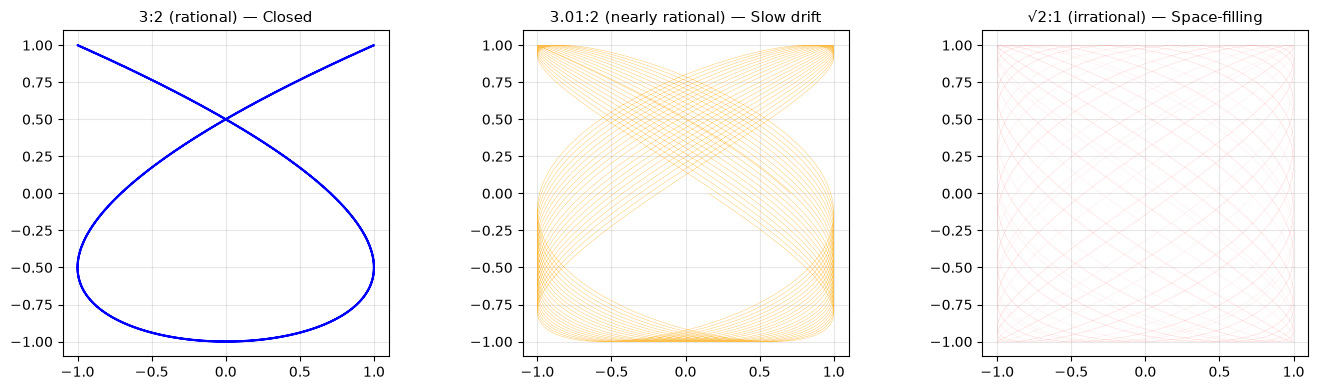

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Closed curve: rational ratio 3:2
t = np.linspace(0, 2*np.pi, 1000)
x = np.cos(3*t + np.pi/4)
y = np.sin(2*t)
axes[0].plot(x, y, 'b-', linewidth=1.5)
axes[0].set_title('3:2 (rational) — Closed', fontsize=11)
axes[0].set_aspect('equal')
axes[0].grid(True, alpha=0.3)

# Almost closed: near-rational ratio
t = np.linspace(0, 20*np.pi, 10000)
x = np.cos(3.01*t + np.pi/4)
y = np.sin(2*t)
axes[1].plot(x, y, 'orange', linewidth=0.3, alpha=0.7)
axes[1].set_title('3.01:2 (nearly rational) — Slow drift', fontsize=11)
axes[1].set_aspect('equal')
axes[1].grid(True, alpha=0.3)

# Never closes: irrational ratio
t = np.linspace(0, 50*np.pi, 50000)
x = np.cos(np.sqrt(2)*t + np.pi/4)
y = np.sin(t)
axes[2].plot(x, y, 'red', linewidth=0.1, alpha=0.3)
axes[2].set_title('√2:1 (irrational) — Space-filling', fontsize=11)
axes[2].set_aspect('equal')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. The Effect of Phase $\delta$

Phase offset changes the visual character while preserving the topology:

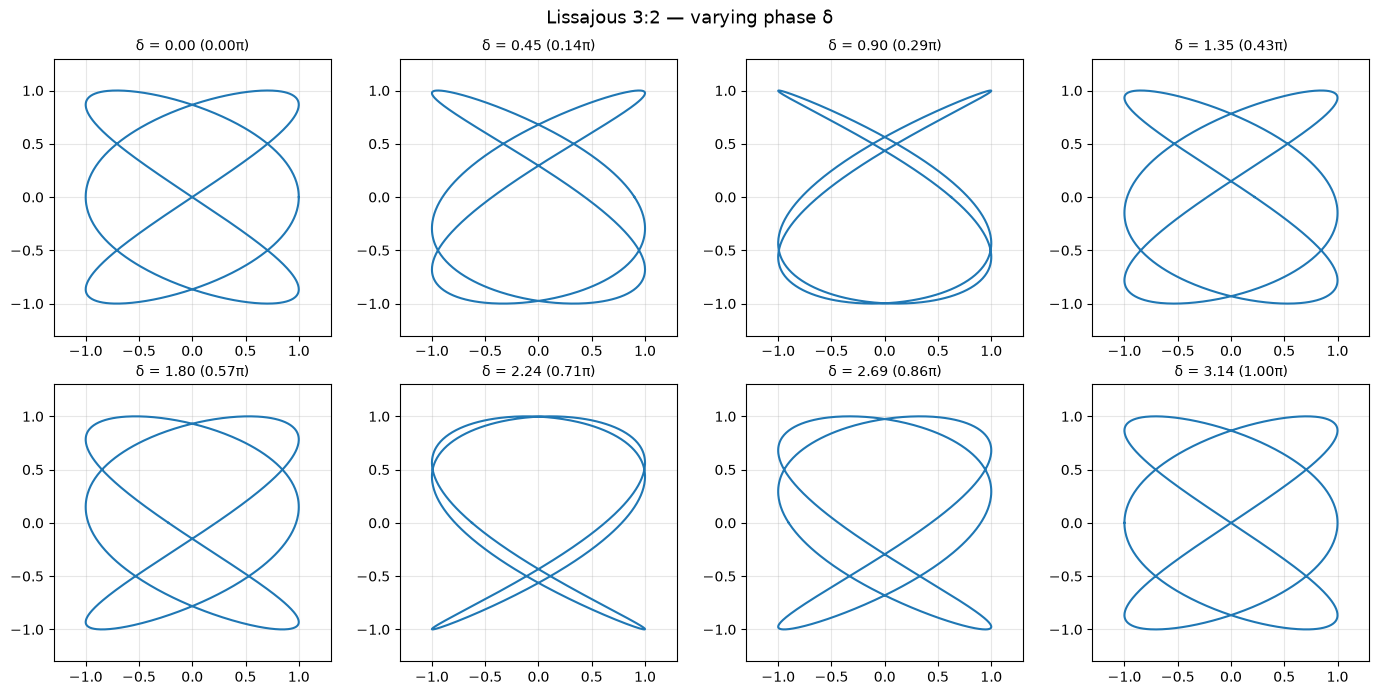

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))

a_val, b_val = 3, 2
delta_values = np.linspace(0, np.pi, 8)

for ax, delta in zip(axes.flat, delta_values):
    x, y = lissajous_2d(a_val, b_val, delta)
    ax.plot(x, y, linewidth=1.5)
    ax.set_title(f'δ = {delta:.2f} ({delta/np.pi:.2f}π)', fontsize=10)
    ax.set_aspect('equal')
    ax.set_xlim(-1.3, 1.3)
    ax.set_ylim(-1.3, 1.3)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Lissajous {a_val}:{b_val} — varying phase δ', fontsize=13)
plt.tight_layout()
plt.show()

## 4. 3D Lissajous Curves

Adding a third frequency gives a 3D curve:

$$x(t) = A \cos(a t + \delta)$$
$$y(t) = B \sin(b t)$$
$$z(t) = C \sin(c t)$$

The curve is closed if *all pairwise* frequency ratios are rational: $a/b$, $a/c$, and $b/c$ must all be rational.

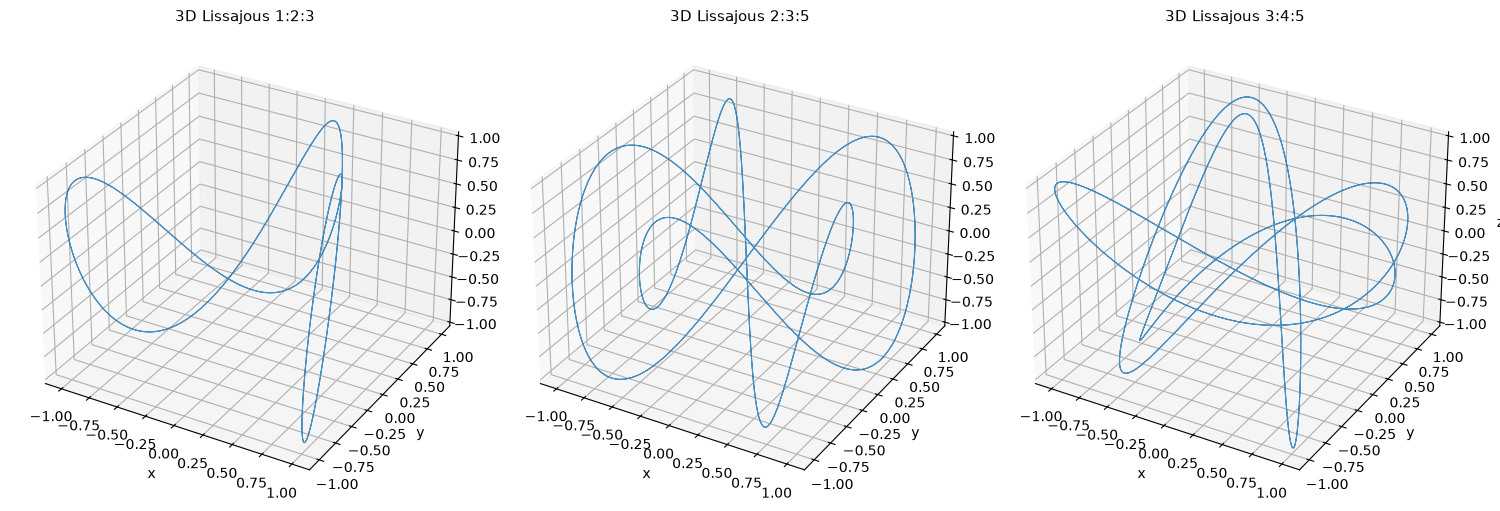

In [4]:
def lissajous_3d(a, b, c, delta=0.0, A=1.0, B=1.0, C=1.0, n_points=2000):
    """Generate a 3D Lissajous curve."""
    # Compute period for closed curves
    from math import gcd
    # Use a generous number of periods
    t = np.linspace(0, 4 * np.pi, n_points)
    
    x = A * np.cos(a * t + delta)
    y = B * np.sin(b * t)
    z = C * np.sin(c * t)
    return x, y, z

fig = plt.figure(figsize=(15, 5))

configs_3d = [
    (1, 2, 3, np.pi/4, '1:2:3'),
    (2, 3, 5, np.pi/2, '2:3:5'),
    (3, 4, 5, np.pi/3, '3:4:5'),
]

for idx, (a, b, c, delta, title) in enumerate(configs_3d):
    ax = fig.add_subplot(1, 3, idx + 1, projection='3d')
    x, y, z = lissajous_3d(a, b, c, delta)
    ax.plot(x, y, z, linewidth=0.8, alpha=0.8)
    ax.set_title(f'3D Lissajous {title}', fontsize=11)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')

plt.tight_layout()
plt.show()

## 5. Using the `physics_modeling` Package

In [5]:
from physics_modeling.oscillators.lissajous import (
    LissajousConfig,
    generate_lissajous,
    is_closed,
)

# Check which curves are closed
test_cases = [
    (1, 2, 3),
    (2, 3, 5),
    (1, np.sqrt(2), 1),
    (1, np.pi, 1),
    (3, 4, 6),
]

print("Frequency ratios and closure:")
print("="*45)
for a, b, c in test_cases:
    closed = is_closed(a, b, c)
    print(f"  a={a}, b={b:.4f}, c={c} → {'CLOSED' if closed else 'OPEN'}")

Frequency ratios and closure:
  a=1, b=2.0000, c=3 → CLOSED
  a=2, b=3.0000, c=5 → CLOSED
  a=1, b=1.4142, c=1 → OPEN
  a=1, b=3.1416, c=1 → OPEN
  a=3, b=4.0000, c=6 → CLOSED


Generated 2000 points in 3D


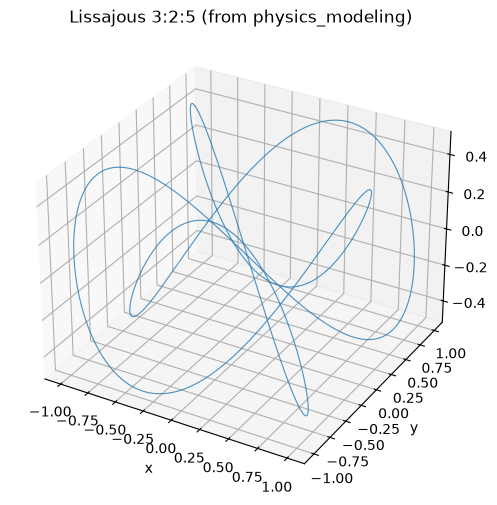

In [6]:
# Generate a curve using the package
config = LissajousConfig(
    a=3, b=2, c=5,
    A=1.0, B=1.0, C=0.5,
    delta=np.pi / 2,
    n_points=2000,
)

points = generate_lissajous(config)
print(f"Generated {points.shape[0]} points in {points.shape[1]}D")

# Plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot(points[:, 0], points[:, 1], points[:, 2], lw=0.8, alpha=0.8)
ax.set_title('Lissajous 3:2:5 (from physics_modeling)', fontsize=12)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.show()

## 6. Gallery: Exploring the Parameter Space

Let's create a systematic grid of frequency ratios:

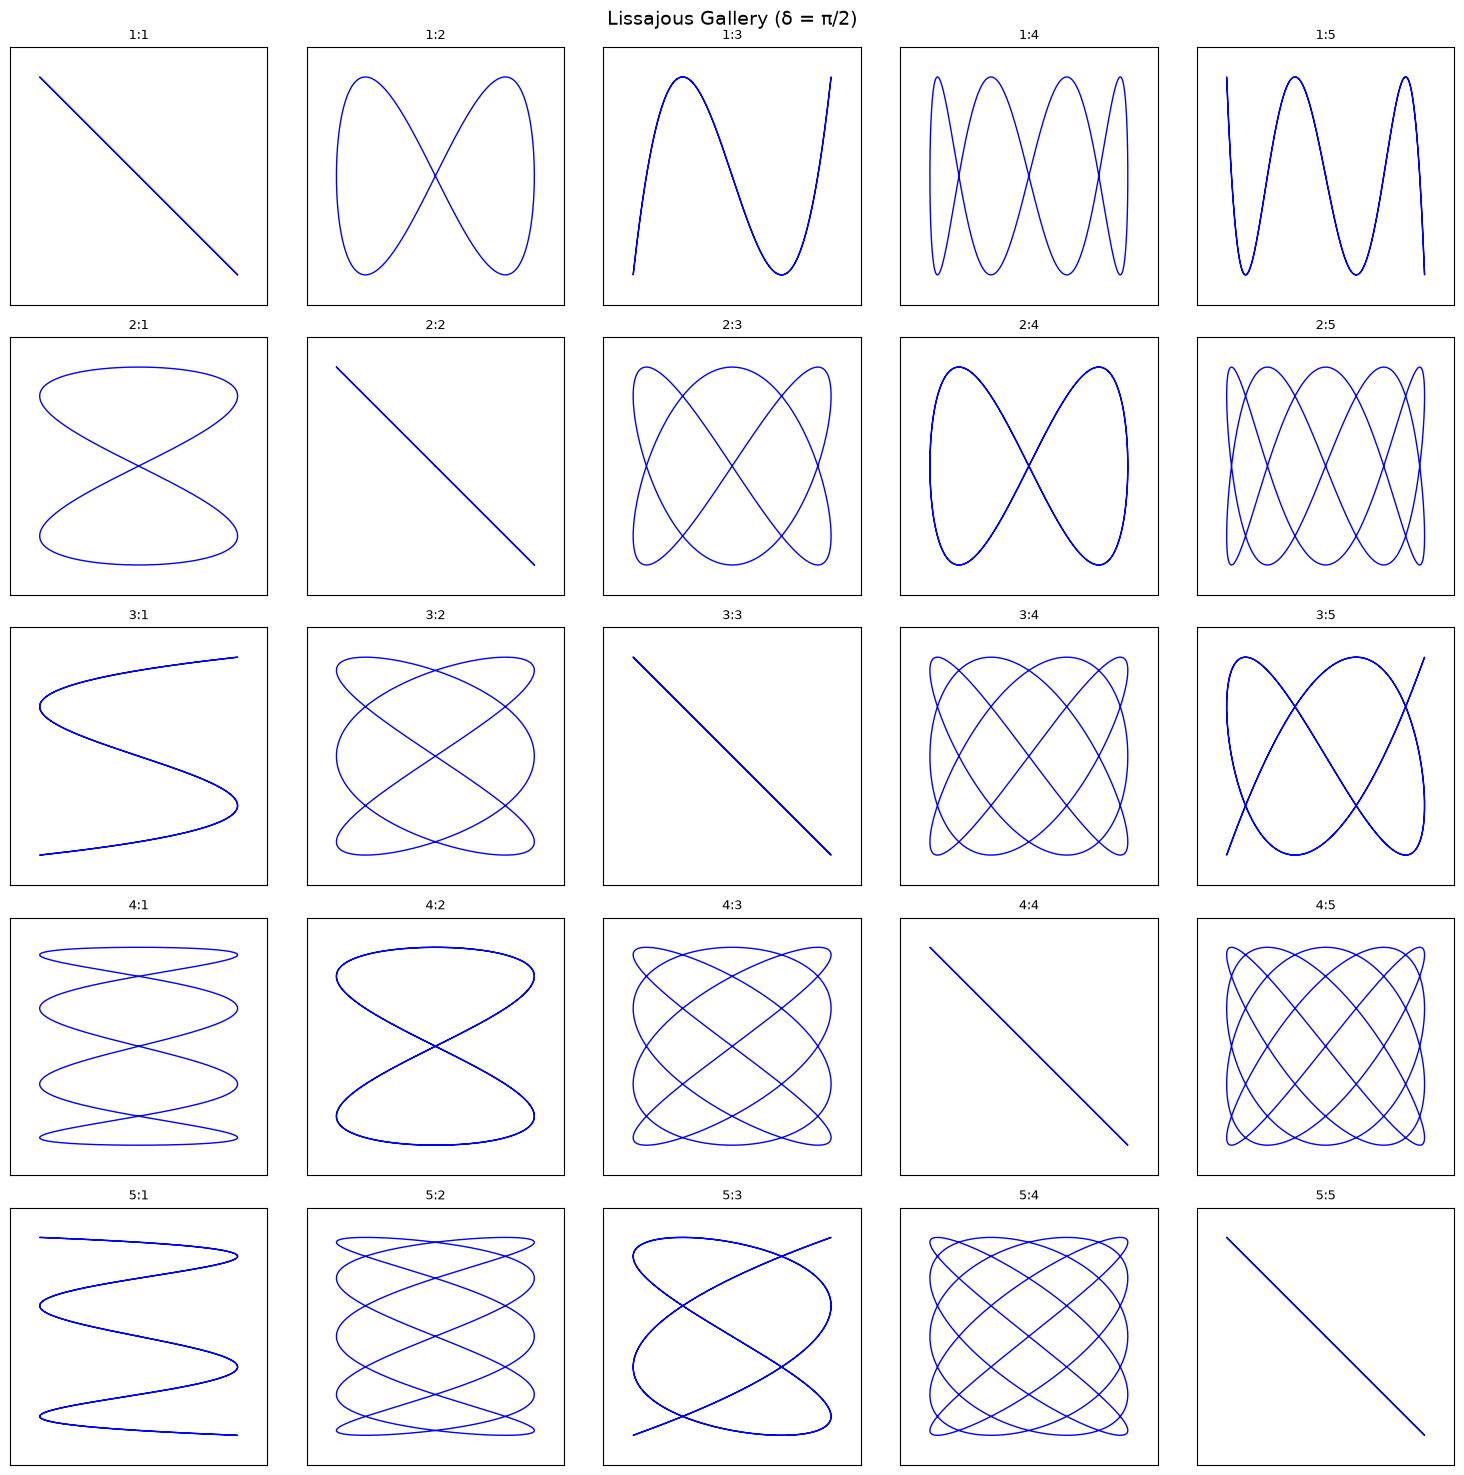

In [7]:
fig, axes = plt.subplots(5, 5, figsize=(15, 15))

for i, a_val in enumerate(range(1, 6)):
    for j, b_val in enumerate(range(1, 6)):
        ax = axes[i, j]
        x, y = lissajous_2d(a_val, b_val, np.pi/2)
        ax.plot(x, y, 'b-', linewidth=1.0)
        ax.set_title(f'{a_val}:{b_val}', fontsize=9)
        ax.set_aspect('equal')
        ax.set_xlim(-1.3, 1.3)
        ax.set_ylim(-1.3, 1.3)
        ax.set_xticks([])
        ax.set_yticks([])

plt.suptitle('Lissajous Gallery (δ = π/2)', fontsize=14)
plt.tight_layout()
plt.show()

## Exercise: Predict Closed Curves

**Tasks:**

1. **Theory**: Write a function `predict_closed(a, b, c)` that determines if a 3D Lissajous curve is closed by checking if all pairwise ratios are rational. Use the `fractions.Fraction` module to test rationality with a tolerance.

2. **Counting crossings**: For a 2D Lissajous with ratio $p:q$ (in lowest terms), the curve makes $p$ horizontal lobes and $q$ vertical lobes. Verify this for several examples.

3. **Near-miss ratios**: Plot Lissajous curves for $a/b = 22/7$ (a rational approximation to $\pi$) and $a/b = \pi$. How long does it take the $\pi$-ratio curve to approximately close?

4. **Challenge**: Find the simplest set of frequencies $(a, b, c)$ that produces a 3D Lissajous knot (a curve that is topologically knotted, not just tangled-looking).

In [8]:
# Your solution here
from fractions import Fraction

def predict_closed(a, b, c, tolerance=1e-9):
    """Predict if a 3D Lissajous curve with frequencies a, b, c is closed.
    
    A curve is closed iff all pairwise frequency ratios are rational.
    """
    def is_rational(x, max_denom=10000):
        """Check if x is approximately rational."""
        frac = Fraction(x).limit_denominator(max_denom)
        return abs(float(frac) - x) < tolerance
    
    return (is_rational(a/b) and is_rational(a/c) and is_rational(b/c))

# Test
print(f"(1, 2, 3) closed? {predict_closed(1, 2, 3)}")
print(f"(1, √2, 1) closed? {predict_closed(1, np.sqrt(2), 1)}")
print(f"(2, 3, 7) closed? {predict_closed(2, 3, 7)}")

# TODO: Count lobes for 2D cases
# TODO: Compare 22/7 vs π ratio

(1, 2, 3) closed? True
(1, √2, 1) closed? False
(2, 3, 7) closed? True
